# Colx 525 Lab Assignment 3: POS Tagging

## Assignment objectives

In this assignment, you will develop a POS tagger using pytorch. You will:

1. Read in training, development and test data using `torchtext`.
1. Implement a baseline majority class tagger.
1. Numericalize data (i.e. transform sentences and words into `torch.Tensor` objects).
1. Develop a BiLSTM POS tagger.  

The [`pytorch` documentation](https://pytorch.org/docs/stable/index.html) will be useful in this lab.

## Getting started

You will need to install the Python modules `torchtext`, `torch` and `numpy`. The easiest way to do this is using `anaconda` or `pip`.

## Tidy Submission

rubric={mechanics:1}

To get the marks for tidy submission:

* Submit the assignment by filling in this jupyter notebook with your answers embedded
* Be sure to follow the general lab instructions
* This is a *paired* lab.  Each member of the team should submit identical labs to their submission repos.  Please indicate clearly who you were working with.

### Exercise 1: Reading in data

We will now read in training development and test sets using the `torchtext` library which can simplify your data handling code. Please have a look at Practical lecture 6.

Before you do anything else, please download the following file, place it in your `Lab3` directory and unzip it:

```
https://https://github.ubc.ca/MDS-CL-2024-25/COLX_525_morphology_students/tree/master/data/uddata.zip
```

We'll start by installing the `conllu` library which can read data Universal Dependencies treebank data. We'll also read the English UD training, development and test set from the `uddata` directory.

In [1]:
import sys
!{sys.executable} -m pip install conllu

In [2]:
import conllu
import os
import torch
from torchtext.vocab import build_vocab_from_iterator
from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pad_sequence

def read_data(dire, lang):
    train_data = conllu.parse(open(os.path.join(dire, f"{lang}-ud-train.conllu.head"), encoding="utf-8").read())
    dev_data = conllu.parse(open(os.path.join(dire, f"{lang}-ud-dev.conllu"), encoding="utf-8").read())
    test_data = conllu.parse(open(os.path.join(dire, f"{lang}-ud-test.conllu"), encoding="utf-8").read())
    return train_data, dev_data, test_data

train_data, dev_data, test_data = read_data("uddata","en")

/Users/lida/miniforge3/envs/colx525/lib/python3.11/site-packages/torchtext/vocab/__init__.py:4: UserWarning: 
/!\ IMPORTANT WARNING ABOUT TORCHTEXT STATUS /!\ 
Torchtext is deprecated and the last released version will be 0.18 (this one). You can silence this warning by calling the following at the beginnign of your scripts: `import torchtext; torchtext.disable_torchtext_deprecation_warning()`
  warnings.warn(torchtext._TORCHTEXT_DEPRECATION_MSG)
/Users/lida/miniforge3/envs/colx525/lib/python3.11/site-packages/torchtext/utils.py:4: UserWarning: 
/!\ IMPORTANT WARNING ABOUT TORCHTEXT STATUS /!\ 
Torchtext is deprecated and the last released version will be 0.18 (this one). You can silence this warning by calling the following at the beginnign of your scripts: `import torchtext; torchtext.disable_torchtext_deprecation_warning()`
  warnings.warn(torchtext._TORCHTEXT_DEPRECATION_MSG)


Let's look at the format of the UD data. We'll print the first token in the first training sentence. As you can see, the token is represented by a dictionary with several fields. For our purposes, the most important ones are:

* `form` which gives the word form, and
* `upos` which gives the Universal Dependencies POS tag. 

In [3]:
len(train_data)
train_data[0][0]

{'id': 1,
 'form': 'Al',
 'lemma': 'Al',
 'upos': 'PROPN',
 'xpos': 'NNP',
 'feats': {'Number': 'Sing'},
 'head': 0,
 'deprel': 'root',
 'deps': None,
 'misc': {'SpaceAfter': 'No'}}

### Exercise 1.1
rubric={accuracy:5}

Following the example in `lecture6` and this [tutorial](https://pytorch.org/tutorials/beginner/data_loading_tutorial.html#dataset-class), implement a `UDDataset` class. It should be a subclass of `torch.utils.data.Dataset`.

Your `__init__` function should take a dataset (`train_data`, `dev_data` or `test_data`) as argument. and assign it as `self.data`. You'll also need to define `__len__` and `__getitem__` member functions which return the length of `self.data` and and element at index `i` respectively.

In [4]:
# Your code here

# Your code here
class UDDataset(torch.utils.data.Dataset):
    # Replace pass with an actual class definition
    def __init__(self, dataset):
        """
        Initializes the dataset object with data.
        :param dataset: List of parsed conllu data.
        """
        self.data = dataset

    def __len__(self):
        """
        Returns the number of sentences in the dataset.
        """
        return len(self.data)

    def __getitem__(self, idx):
        """
        Retrieves the idx-th sentence from the dataset.
        :param idx: Index of the sentence to retrieve.
        :return: The sentence at the specified index.
        """
        return self.data[idx]

In [5]:
train = UDDataset(train_data)

### Exercise 1.2
rubric={accuracy:5}

We'll now compile three vocabularies: one for words, one for characters and one for POS tags. 

Let's start by initializing generators for words (`yield_tokens`), characters (`yield_chars`) and POS tags (`yield_pos`). These extract words, characters and POS tags from a batch of examples. 

Note, that:
* `yield_tokens` generates a list of tokens: `["the", "dog", "sleeps"]`
* `yield_chars` generates a list of characters: `["t", "h", "e", "d", "o", "g", "s", "l", "e", "e", "p", "s"]` (notice the lack of spaces between words)
* `yield_pos` generates a list of POS tags: `["DET","NOUN","VERB"]`

In [6]:
def yield_tokens(data):
    for ex in data:
        yield([tok["form"] for tok in ex])
        
def yield_chars(data):
    for ex in data:
        yield([c for tok in ex for c in tok["form"]])
        
def yield_pos(data):
    for ex in data:
        yield([tok["upos"] for tok in ex])

print("First training example:")
print("Tokens:",next(yield_tokens(train)))
print("Characters:", next(yield_chars(train)))
print("POS:", next(yield_pos(train)))

First training example:
Tokens: ['Al', '-', 'Zaman', ':', 'American', 'forces', 'killed', 'Shaikh', 'Abdullah', 'al', '-', 'Ani', ',', 'the', 'preacher', 'at', 'the', 'mosque', 'in', 'the', 'town', 'of', 'Qaim', ',', 'near', 'the', 'Syrian', 'border', '.']
Characters: ['A', 'l', '-', 'Z', 'a', 'm', 'a', 'n', ':', 'A', 'm', 'e', 'r', 'i', 'c', 'a', 'n', 'f', 'o', 'r', 'c', 'e', 's', 'k', 'i', 'l', 'l', 'e', 'd', 'S', 'h', 'a', 'i', 'k', 'h', 'A', 'b', 'd', 'u', 'l', 'l', 'a', 'h', 'a', 'l', '-', 'A', 'n', 'i', ',', 't', 'h', 'e', 'p', 'r', 'e', 'a', 'c', 'h', 'e', 'r', 'a', 't', 't', 'h', 'e', 'm', 'o', 's', 'q', 'u', 'e', 'i', 'n', 't', 'h', 'e', 't', 'o', 'w', 'n', 'o', 'f', 'Q', 'a', 'i', 'm', ',', 'n', 'e', 'a', 'r', 't', 'h', 'e', 'S', 'y', 'r', 'i', 'a', 'n', 'b', 'o', 'r', 'd', 'e', 'r', '.']
POS: ['PROPN', 'PUNCT', 'PROPN', 'PUNCT', 'ADJ', 'NOUN', 'VERB', 'PROPN', 'PROPN', 'PROPN', 'PUNCT', 'PROPN', 'PUNCT', 'DET', 'NOUN', 'ADP', 'DET', 'NOUN', 'ADP', 'DET', 'NOUN', 'ADP', 'PROP

Following the example in `lecture 6`, use `build_vocab_from_iterator` and the **training set** to define:

* a word vocabulary `word_vocab` based on the tokens generated by `yield_tokens`. Your vocabulary should contain the special symbols: \<unk\>, \<start\> and \<end\>
* a character vocabulary `char_vocab` based on the tokens generated by `yield_chars`. Your vocabulary should contain the special symbols: \<unk\>, \<start\>, \<end\> and \<pad\>
* a pos vocabulary `pos_vocab` based on the tokens generated by `yield_pos`. Your vocabulary should contain the special symbol: \<unk\>

**Hint:** Remember to call `set_default_index` to set the ID for the \<unk\> token.

In [7]:
# Your code here
from torchtext.vocab import build_vocab_from_iterator
from collections import Counter

def build_vocabulary(data_iterator, specials):
    """
    Build a vocabulary from an iterator.
    :param data_iterator: An iterator that yields lists of elements (tokens, characters, or tags).
    :param specials: A list of special tokens to include in the vocabulary.
    """
    # Counter to hold all tokens and their frequencies
    counter = Counter()
    for data in data_iterator:
        counter.update(data)
    # Return a vocabulary built from the counter and include special tokens
    vocab = build_vocab_from_iterator([counter.keys()], specials=specials)
    vocab.set_default_index(vocab["<unk>"])
    return vocab

# Build vocabularies
word_vocab = build_vocabulary(yield_tokens(train), specials=["<unk>", "<start>", "<end>"])
char_vocab = build_vocabulary(yield_chars(train), specials=["<unk>", "<start>", "<end>", "<pad>"])
pos_vocab = build_vocabulary(yield_pos(train), specials=["<unk>"])

# Printing some example data from the vocabularies
print("Word Vocabulary:", list(word_vocab.get_stoi().items())[:10])  # Show first 10 entries
print("Character Vocabulary:", list(char_vocab.get_stoi().items())[:10])  # Show first 10 entries
print("POS Vocabulary:", list(pos_vocab.get_stoi().items())[:10])  # Show first 10 entries

Word Vocabulary: [('“', 4737), ('’’', 4736), ('’73', 4734), ('’', 4732), ('yuor', 4727), ('youth', 4726), ('yourself', 4725), ('your', 4724), ('you', 4720), ('yesterday', 4718)]
Character Vocabulary: [('“', 94), ('’', 93), ('é', 90), ('Ã', 89), ('³', 88), ('w', 84), ('v', 83), ('t', 81), ('s', 80), ('r', 79)]
POS Vocabulary: [('X', 17), ('VERB', 16), ('SYM', 15), ('SCONJ', 14), ('PUNCT', 13), ('PRON', 11), ('NUM', 9), ('INTJ', 7), ('DET', 6), ('PROPN', 12)]


### Exercise 1.3
rubric={accuracy:10}

We'll now write a `collate_batch` function which numericalizes a batch of examples into torch tensors.

We'll use the following transformation functions which tokenize and numericalize the tokens, characters and POS tags, respectively. Note that both `word_transform` and `char_transform` add \<start\> and \<end\> tokens to the input. 

In [8]:
word_transform = lambda s: [word_vocab[w] for w in ["<start>"] + s + ["<end>"]]
pos_transform = lambda s: [pos_vocab[w] for w in s]
char_transform = lambda w: [char_vocab[c] for c in ["<start>"] + w + ["<end>"]]

The function `collate_batch` takes a batch of examples as input. It extracts the tokens, characters and POS tags for each example using `yield_tokens`, `yield_chars` and `yield_pos`, respectively.

Your first task to use `word_transform` and `pos_transform` to transform token and POS lists into torch tensors (with data type `torch.long`). You should store the tensors as `token_tensor` and `pos_tensor`. `token_tensor` should have size `sentence_length + 2 x 1` and `pos_tensor` will have size `sentence_length x 1`. The `+ 2` comes from adding start and end symbols to `tokens`. 

**Hint:** You may need to call the torch function [`unsqueeze`](https://pytorch.org/docs/stable/generated/torch.unsqueeze.html#torch.unsqueeze) to ensure the correct size.

Your second task is to convert `chars` into a list of tensors of shape `1 x word_length`. Remember that `yield_chars` returns a long list containing all the characters in the input sentence. You should first split this up into a list containing inidividual words like `["t", "h", "e"]` using the function `split_char_sequence`. Store the result as `chars`.

You can then use `char_transform` to numericalize each word in `chars`. Again, store the resulting list as `chars`. Finally, compile each numericalized word in `chars` into a torch tensor with dtype `torch.long`. Store the result as `char_tensor`. 

In [9]:
from itertools import islice
from collections import namedtuple
Example = namedtuple("Example",["word", "pos", "char"])

def split_char_sequence(chars, tokens):
    """ Split a sequence of characters representing a sentence into 
        sequences representing the individual words in the sentence
        
        ["t","h","e","d","o","g","s","l","e","e","p","s"] ->
        [["t","h","e"], ["d","o","g"], ["s","l","e","e","p","s"]]
        
        Arguments:
        
        chars: A list of chars ["t","h","e","d","o","g","s","l","e","e","p","s"]
        tokens: A list of tokens ["the", "dog", "sleeps"]
    """
    word_lens = [len(w) for w in tokens]
    chars = iter(chars)
    return [list(islice(chars, elem)) for elem in word_lens]
    
def collate_batch(batch):
    pos_list, token_list, char_list, word_lens = [], [], [], []
    for tokens, chars, pos in zip(yield_tokens(batch), 
                                  yield_chars(batch),
                                  yield_pos(batch)):
        # Your code here
        token_tensor = torch.tensor(word_transform(tokens), dtype=torch.long).unsqueeze(1)
        pos_tensor = torch.tensor(pos_transform(pos), dtype=torch.long).unsqueeze(1)

        chars = split_char_sequence(chars, tokens)

        char_tensors = [torch.tensor(char_transform(word), dtype=torch.long) for word in chars]
        
        max_word_length = max(len(x) for x in char_tensors)
        char_tensors = [
            torch.cat([
                x, 
                torch.full(
                    (max_word_length - len(x),), 
                    char_vocab["<pad>"], 
                    dtype=torch.long
                )
            ]) if len(x) < max_word_length else x
            for x in char_tensors
        ]
        
        char_tensor = torch.stack(char_tensors, dim=0)
        # Your code here
        pos_list.append(pos_tensor)
        token_list.append(token_tensor)
        char_list += char_tensors

    return Example(token_list[0],
                   pos_list[0],
                   (pad_sequence(char_list, batch_first=True, padding_value=char_vocab["<pad>"]).unsqueeze(0),
                    len(token_list[0])-2,
                    [len(w) for w in tokens]))

In [10]:
# Some assertions to check your code
b = collate_batch(dev_data[0:1])
assert(b.word.size()[0] == len(dev_data[0]) + 2)
assert(b.pos.size()[0] == len(dev_data[0]))
chars, _, _ = b.char
assert(chars.size()[2] == len(dev_data[0]))
assert(chars.size()[1] == max([len(tok["form"]) for tok in dev_data[0]]) + 2)

Let's then use the function to numericalize the training, development and test data. Note, that we set `shuffle=True` for the training set.

In [11]:
dev_iter = DataLoader(dev_data, batch_size=1, shuffle=False, collate_fn=collate_batch)
test_iter = DataLoader(test_data, batch_size=1, shuffle=False, collate_fn=collate_batch)
train_iter = DataLoader(train_data, batch_size=1, shuffle=True, collate_fn=collate_batch)

We'll then take a closer look at the examples in our datasets:

In [12]:
ex = next(iter(dev_iter))

print("ex.word is a tensor containing the word tokens in the sentence:")
print(ex.word)
print("It has size sentence_length+2 x 1:")
print(ex.word.size())
print()
print("ex.pos is a tensor containing the POS tags in the sentence:")
print(ex.pos)
print("It has size sentence_length x 1:")
print(ex.pos.size())
print()
print("ex.char is a tuple having three elements:")
char_tensor, sentence_length, word_lengths = ex.char
print("char_tensor contains character-sequence representations of the tokens in the sentence")
print(char_tensor)
print("It has size 1 x sentence_length x sequence_length:")
print(char_tensor.size())
print()
print("sentence_length simply gives the sentence_length (without <start> and <end> tokens):")
print(sentence_length)
print()
print("word_lengths contains the length of each word in the sentence (without <start> and <end> tokens):")
print(word_lengths)

ex.word is a tensor containing the word tokens in the sentence:
tensor([[   1],
        [ 521],
        [4345],
        [   0],
        [1857],
        [4368],
        [4200],
        [ 145],
        [   2]])
It has size sentence_length+2 x 1:
torch.Size([9, 1])

ex.pos is a tensor containing the POS tags in the sentence:
tensor([[ 2],
        [ 6],
        [12],
        [16],
        [ 6],
        [ 8],
        [13]])
It has size sentence_length x 1:
torch.Size([7, 1])

ex.char is a tuple having three elements:
char_tensor contains character-sequence representations of the tokens in the sentence
tensor([[[ 1, 38, 79, 76, 74,  2,  3],
         [ 1, 81, 69, 66,  2,  3,  3],
         [ 1, 33, 48,  2,  3,  3,  3],
         [ 1, 64, 76, 74, 66, 80,  2],
         [ 1, 81, 69, 70, 80,  2,  3],
         [ 1, 80, 81, 76, 79, 86,  2],
         [ 1, 29,  2,  3,  3,  3,  3]]])
It has size 1 x sentence_length x sequence_length:
torch.Size([1, 7, 7])

sentence_length simply gives the sentence_lengt

### Exercise 2: Simple baseline tagger

To be able to gauge the performance of our deep learning tagger, we'll now implement a baseline majority label classifier.

#### Exercise 2.1: Counting tags

rubric={accuracy:5}

As a first step, you will count the occurrences of different POS tags for each word in the **training data**. These counts will be stored in `tag_counts` below. For example, `tag_counts["this"]["PRON"]` should tell you how many times the word "this" was tagged `PRON` in the training data.

In [13]:
from collections import defaultdict, Counter

# A counter for POS tags. tag_counts[wf][pos] should denote the number of times we saw the word wf with 
# POS tag pos in the training data.
tag_counts = defaultdict(Counter)

# Populate tag_counts with the counts of different POS tags for each word type in the training data. 
# your code here
for sentence in train_data:
    for token in sentence:
        word_form = token['form']
        pos_tag = token['upos']
        tag_counts[word_form][pos_tag] += 1
# your code here
# A few assertions to make sure that your code is working properly.
assert(tag_counts["this"]["DET"] == 46)
assert(tag_counts["this"]["PRON"] == 20)
assert(tag_counts["this"]["ADV"] == 1)

#### Exercise 2.2 Tagging the development data

rubric={accuracy:5}

The next step is to tag the development data. For each example in the development set, you should append a list of predicted POS tags to `output_tags`. 

For each word in an example, output its most common tag given by `tag_counts`. For OOV (out-of-vocabulary) words which are missing from `tag_counts`, you can predict `NOUN`. 

In [14]:
output_tags = []
word_itos = word_vocab.get_itos()

for ex in dev_iter:
    output_tags.append([])
    for wf in ex.word[1:-1]:
        wf = word_itos[wf]
        # your code here
        if wf in tag_counts:
            # Get the most common POS tag for the word from tag_counts
            most_common_tag = tag_counts[wf].most_common(1)[0][0]
            output_tags[-1].append(most_common_tag)
        else:
            # Default to 'NOUN' if the word is out of vocabulary
            output_tags[-1].append('NOUN')
        # your code here

Using the `accuracy` function below, you can now print the baseline tagging accuracy on the development set. It should be around 77%.

In [15]:
def accuracy(sys,gold):
    """
    Function for evaluating tagging accuracy w.r.t. a gold standard test set (gold).
    """
    assert(len(sys) == len(gold))
    corr = 0
    tot = 0
    pos_itos = pos_vocab.get_itos()
    for s, g in zip(sys,gold):
        assert(len(s) == len(g.pos))
        corr += sum([1 if x==pos_itos[y] else 0 for x,y in zip(s,g.pos)])
        tot += len(s)
    return corr * 100.0 / tot

print("Accuracy for baseline majority class tagger:",accuracy(output_tags,dev_iter))

Accuracy for baseline majority class tagger: 77.36599331954828


### Exercise 3: The POS tagger

In this exercise, you will build a basic BiLSTM POS tagger. The tagger:

1. Embeds word tokens in the input sentence.
2. Passes the embeddings through a bidirectional LSTM layer.
3. Predicts POS tags using a feed-forward network and log softmax layer.

When you are implementing the POS tagger, remember to always keep track of the input and output sizes of all of you tensors. It is very important to check that these are correct. It is also important to understand what your dimensions refer to.

Let's start by loading a few necessary libraries and setting hyper-parameters:

In [16]:
import numpy as np

import torch
import torch.nn as nn
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
from torch.nn.functional import log_softmax, relu
from torch.optim import Adam, SGD

from random import random, seed, shuffle

# Ensure reproducible results by setting random seeds to 0.
seed(0)
torch.manual_seed(0)
np.random.seed(0)

import re

# Hyperparameters
EMBEDDING_DIM=300
RNN_HIDDEN_DIM=50
RNN_LAYERS=1
BATCH_SIZE=1
EPOCHS=5

# Maximum length of generated output word forms.
MAXWFLEN=40

#### Exercise 3.1: LSTM layer

rubric={accuracy:15}

You should implement a `BidirectionalLSTM` class which is used to encode a sequence of word embeddings into  representations. `BidirectionalLSTM` encapsulates two LSTM networks: `self.forward_rnn` and `self.backward_rnn` which you should initialize in `BidirectionalLSTM.__init__`. Both should have:

1. Embedding dimension `self.embedding_dim` (this is a parameter to the `__init__` function)
1. Hidden dimension `RNN_HIDDEN_DIM` 
1. Layer count `RNN_LAYERS`

Your second task is to implement the `BidirectionalLSTM.forward` function. As argument, the function takes a `torch.Tensor` `sequence` which has size `(sequence_length,1,EMBEDDING_DIM)`. This tensor contains the word embeddings for the input sentence.  

You should pass the `sequence` to `self.forward_rnn` which returns:

1. a sequence $f_1,...,f_n$ of forward hidden states represented as a tensor `fwd_hss` having size `(sequence_length,1,RNN_HIDDEN_DIM)` and
1. a pair `(fwd_hs, fwd_cs)`, where:
   1. `fwd_hs` is the final forward hidden state having dimension `(1,1,RNN_HIDDEN_DIM)`.
   1. `fwd_cs` is the final forward cell state having dimension `(1,1,RNN_HIDDEN_DIM)`.
   
You should pass the **reversed** `sequence` to `self.backward_rnn` (**HINT**: [`torch.flip`](https://pytorch.org/docs/stable/torch.html#torch.flip) can be useful here) which returns:

1. a sequence $b_n,...,b_1$ of backward hidden states represented as a tensor `bwd_hss` having size `(sequence_length,1,RNN_HIDDEN_DIM)` (NOTE! the backward states are reversersed here) 
1. and a pair `(bwd_hs, bwd_cs)`, where:
   1. `bwd_hs` is the final backward hidden state having dimension `(1,1,RNN_HIDDEN_DIM)`.
   1. `bwd_cs` is the final backward cell state having dimension `(1,1,RNN_HIDDEN_DIM)`.
   
The `forward` function should return a tensor `hss` having dimension `(sequence_length, 1, 2*self.hidden_dim)`, where `hss[i]` represents the concatenation of the $i$th forward hidden state $f_i$ and the $i$th backward hidden state $b_i$ (**HINT**: Again `torch.flip` can be useful).

In [17]:
class BidirectionalLSTM(nn.Module):
    def __init__(self, embedding_dim=EMBEDDING_DIM):
        super(BidirectionalLSTM, self).__init__()
        self.embedding_dim = embedding_dim
        self.hidden_dim = RNN_HIDDEN_DIM

        # Define forward LSTM
        self.forward_rnn = nn.LSTM(input_size=self.embedding_dim,
                                   hidden_size=self.hidden_dim,
                                   num_layers=RNN_LAYERS,
                                   batch_first=False)

        # Define backward LSTM
        self.backward_rnn = nn.LSTM(input_size=self.embedding_dim,
                                    hidden_size=self.hidden_dim,
                                    num_layers=RNN_LAYERS,
                                    batch_first=False)       

    def forward(self, sequence):
        """
        Args:
            sequence: (sequence_length, 1, EMBEDDING_DIM)
        
        Returns:
            hss: (sequence_length, 1, 2*RNN_HIDDEN_DIM)
        """
        
        # Forward LSTM processing
        fwd_hss, (fwd_hs, fwd_cs) = self.forward_rnn(sequence)
        # fwd_hss: (sequence_length, 1, RNN_HIDDEN_DIM)
        # fwd_hs: (1, 1, RNN_HIDDEN_DIM)  # Last hidden state
        # fwd_cs: (1, 1, RNN_HIDDEN_DIM)  # Last cell state

        # Reverse sequence for backward LSTM
        reversed_sequence = torch.flip(sequence, dims=[0])

        # Backward LSTM processing
        bwd_hss, (bwd_hs, bwd_cs) = self.backward_rnn(reversed_sequence)
        # bwd_hss: (sequence_length, 1, RNN_HIDDEN_DIM)

        # Reverse backward hidden states to match the original order
        bwd_hss = torch.flip(bwd_hss, dims=[0])

        # Concatenate forward and backward hidden states
        hss = torch.cat((fwd_hss, bwd_hss), dim=2)
        # hss: (sequence_length, 1, 2*RNN_HIDDEN_DIM)

        return hss
assert(BidirectionalLSTM()(torch.zeros(10,1,EMBEDDING_DIM)).size() == (10,1,2*RNN_HIDDEN_DIM))

In order to improve tagging accuracy for OOV words, we need to use word dropout. It takes two arguments:
1. A `torch.Tensor` `sequence` of size `(sequence_length,1)` and
1. A float `word_dropout` in the interval `[0,1]`.
During training, the function randomly replaces words by `word_vocab["<unk>"]` with probability 'word_dropout'.  

In [18]:
def drop_words(sequence,word_dropout):
    seq_len, _ = sequence.size()
    dropout_sequence = sequence.clone()
    for i in range(1,seq_len-1):
        if random() < word_dropout:
            dropout_sequence[i,0] = word_vocab["<unk>"]
    return dropout_sequence
    
# Assertions to check that your code returns objects of the correct size (not a guarantee that your code works).
assert(drop_words(torch.zeros(10,1),0.5).size() == (10,1))

#### Exercise 3.2 Sentence Encoder 

rubric={accuracy:15}

Your next task is to build a class `SentenceEncoder` which takes an example (from `train_iter`, `dev_iter` or `test_iter`) as input and returns a sequence of LSTM hidden states given by `BidirectionalLSTM`.

You first task is to initialize the `SentenceEncoder` class. You will initialize 3 class-members:
1. `self.vocabulary` which is just an alias for `word_vocab`.
1. `self.embeddings` which is a `torch.nn.Embedding` having input dimension `len(self.vocabulary)` and output dimension `EMBEDDING_DIM`. (This is just transforming a sparse vector into a dense one.)
1. `self.rnn` which is a `BidirectionalLSTM` object.

You should then implement `SentenceEncoder.forward` which takes as example `ex` as input. Additionally, it takes another parameter `word_dropout` which is the probability for word dropout on the sentence `ex`. The function should:
1. Perform word dropout on `ex` by calling the `drop_words` function above.
1. Embed the resulting tensor resulting in a tensor `embedded`.
1. Run `self.rnn` on embedded.
1. Return the resulting representation tensor. However, `ex.word` represents a sentence where we have appended an initial symbol `START` and final symbol `END`. You need to therefore clip the first and last representation vector before returning the output of `self.rnn`.

In [19]:
class SentenceEncoder(nn.Module):
    def __init__(self):
        super(SentenceEncoder, self).__init__()

        # Initialize vocabulary
        self.vocab = word_vocab

        # Word embedding layer
        self.embedding_layer = nn.Embedding(
            num_embeddings=len(self.vocab), 
            embedding_dim=EMBEDDING_DIM
        )
        
        # BiLSTM for encoding
        self.bilstm = BidirectionalLSTM()        

    def forward(self, ex, word_dropout):
        """
        Encodes the input sentence with word dropout and BiLSTM processing.
    
        Args:
            ex: An Example object with sentence data.
            word_dropout (float): Probability to replace words with <unk>.
        
        Returns:
            torch.Tensor: The output of the BiLSTM, excluding <start> and <end> tokens.
        """
        # Adjust input to ensure proper shape
        word_sequence = ex.word.unsqueeze(1) if ex.word.dim() == 1 else ex.word
    
        # Apply word dropout
        dropped_sequence = drop_words(word_sequence, word_dropout)  # (sequence_length, 1)
    
        # Convert words into embeddings
        embedded_sequence = self.embedding_layer(dropped_sequence)  # (sequence_length, 1, EMBEDDING_DIM)
    
        # Pass through BiLSTM
        bi_lstm_output = self.bilstm(embedded_sequence)  # (sequence_length, 1, 2*RNN_HIDDEN_DIM)
    
        # Remove <start> and <end> token representations
        return bi_lstm_output[1:-1]  # (sentence_length, 1, 2*RNN_HIDDEN_DIM)
       
ex = next(iter(dev_iter))
sentence_length = ex.word.size()[0] - 2
assert(SentenceEncoder()(ex, 0.5).size() == (sentence_length, 1, 2*RNN_HIDDEN_DIM))

#### Exercise 3.3: Prediction Layer

rubric={accuracy:15}

Your next task is to implement a feed-forward network `FeedForward` which is used to predict tags from LSTM representations. The constructor `feedForward.__init__` takes two arguments `input_dim` and `output_dim` representing the input and output dimension of the network, respectively. 
Your first task is to complete the function `FeedForward.__init__` by initializing two linear layers:
1. `self.linear1` having input dimension `input_dim` and output dimension `input_dim` and
2. `self.linear2` having input dimension `input_dim` and output dimension `output_dim`.

Your second task is to implement the function `FeedForward.forward`. As input, the function takes `tensor` which is a torch.Tensor object having size `(sequence_length, 1, input_dim)`. It then:
1. Applies `self.linear1` followed by a ReLU activation function on `tensor` and
2. then passes the result through `self.linear2` and a `log_softmax` layer and finally returns the result.

In [20]:
import torch.nn.functional as F

class FeedForward(nn.Module):
    def __init__(self, input_dim, output_dim):
        """
        Args:
            input_dim (int): Dimension of input tensor (should match BiLSTM output).
            output_dim (int): Number of output classes (e.g., POS tag count).
        """
        super(FeedForward, self).__init__()

        # Initialize layers
        # First linear layer: input_dim -> input_dim (hidden layer)
        self.fc1 = nn.Linear(input_dim, input_dim)

        # Second linear layer: input_dim -> output_dim (final output layer)
        self.fc2 = nn.Linear(input_dim, output_dim)

    def forward(self, tensor):
        """
        Forward pass for FeedForward POS tag predictor.
        
        Args:
            tensor (torch.Tensor): LSTM hidden states of shape (sequence_length, 1, input_dim)
        
        Returns:
            torch.Tensor: Predicted logits with shape (sequence_length, 1, output_dim)
        """
        # Apply first linear layer + ReLU activation
        hidden = F.relu(self.fc1(tensor))

        # Apply second linear layer + log_softmax for output
        output = F.log_softmax(self.fc2(hidden), dim=-1)

        return output

# Assertions to check that your code returns objects of the correct size (not a guarantee that your code works).
assert(FeedForward(2*RNN_HIDDEN_DIM, 100)(torch.zeros(10, 1, 2*RNN_HIDDEN_DIM)).size() == (10, 1, 100))

## Tagging sentences and training the model

Now it's time to put together all the components that you built so far. `SimplePOSTagger` is a wrapper around a `SentenceEncoder` and `FeedForward` layer. It has a `forward` method which returns a tensor `res` where `res[i,j]` represents the log probability of tag `pos_vocab.get_itos()[j]` for the word at position `i` in our input sentences. 

The function `tag` gets POS tags for a dataset `data`.  

In [21]:
class SimplePOSTagger(nn.Module):
    def __init__(self):
        super(SimplePOSTagger,self).__init__()
        self.tagset_size = len(pos_vocab)
        
        self.sentence_encoder = SentenceEncoder()
        self.hidden2tag = FeedForward(2*RNN_HIDDEN_DIM,self.tagset_size)
        
    def forward(self,ex, word_dropout=0):
        states = self.sentence_encoder(ex,word_dropout)
        return self.hidden2tag(states)

    def tag(self,data):
        with torch.no_grad():
            results = []
            pos_itos = pos_vocab.get_itos()
            for ex in data:
                tags = self(ex).argmax(dim=2).squeeze(1)
                results.append([pos_itos[i] for i in tags])
            return results
        
pos_size = len(pos_vocab)
ex = next(iter(dev_iter))
assert(SimplePOSTagger()(ex).size() == (ex.word.size()[0]-2,1,pos_size))
assert(len(SimplePOSTagger().tag([ex])[0]) == ex.word.size()[0] -2) 

Armed with the `SimplePOSTagger` class, you can now train your tagger using the following code. You should get to around 75% tagging accuracy on the development set.

In [22]:
tagger = SimplePOSTagger()
optimizer = Adam(tagger.parameters())
loss_function = nn.NLLLoss()

for epoch in range(EPOCHS):
    tot_loss = 0
    for i,ex in enumerate(train_iter):
        print("Epoch %u: Example %u of %u" % (epoch+1, i+1,len(train)),end="\r")
        tagger.zero_grad()
        output = tagger(ex,word_dropout=0.05).squeeze(dim=1)
        gold = ex.pos.squeeze(dim=1)
        loss = loss_function(output,gold)
        loss.backward()
        optimizer.step()
        tot_loss += loss.detach().numpy()
    print("\nAverage loss per example: %.4f" % (tot_loss/len(train_iter)))
    sys_dev = tagger.tag(dev_iter)
    print("Development accuracy: %.2f" % accuracy(sys_dev, dev_iter))

Epoch 1: Example 1000 of 1000
Average loss per example: 1.2465
Development accuracy: 71.81
Epoch 2: Example 1000 of 1000
Average loss per example: 0.4948
Development accuracy: 73.72
Epoch 3: Example 1000 of 1000
Average loss per example: 0.2514
Development accuracy: 77.28
Epoch 4: Example 1000 of 1000
Average loss per example: 0.1868
Development accuracy: 77.00
Epoch 5: Example 1000 of 1000
Average loss per example: 0.1630
Development accuracy: 77.00


You may notice that this is almost the same accuracy as for our baseline model. You can get a bit higher if you raise the number of epochs. If you really want better accuracy, you'll have to implement a character-level model and use pretrained embeddings. These can get you up to 85%.

#### Exercise 3.4 Error breakdown
rubric={accuracy:2, reasoning:2}

Now that you've established both a baseline and a better tagger, reconfigure your evaluation metric to build a confusion matrix for both the baseline and the tagger.

Your confusion matrix should compare each part of speech to each other part of speech, to determine the likelihood that a gold POS was misclassified as something else.  It should also contain an overall accuracy for each part of speech.  The results should be printed in a table.

For example, the "VB" row in your table may look like the following:

VB | 5 | 2 | 5 | 88 | 88% |

Where the columns represent instances that should be verbs, but were tagged as nouns, adjectives, adverbs, and verbs, respectively (with the final column reporting the final results).

Which 3 POS improve the most from using an informed classifier?  Do any get worse?  Which false categories get "fixed" the most?

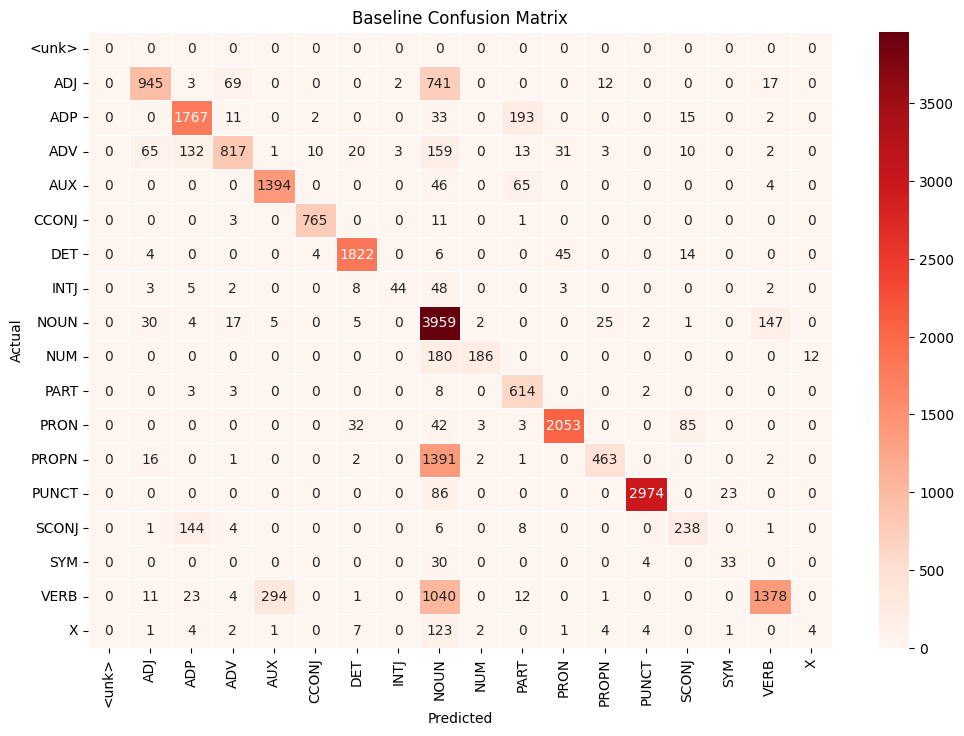

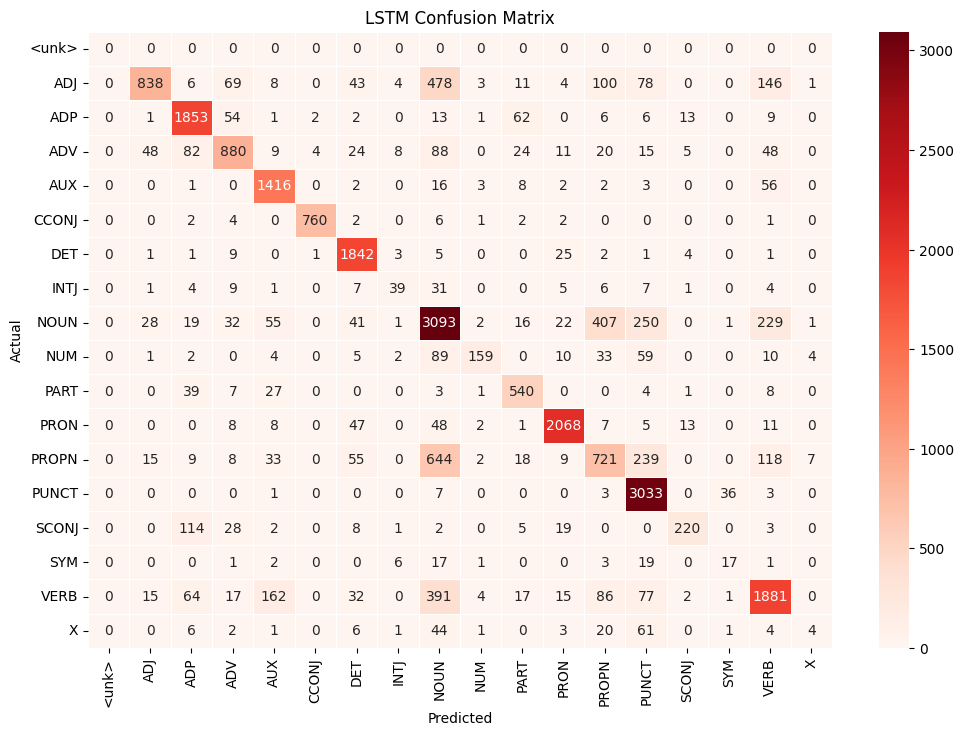

Top 3 POS with highest improvement:
 VERB     18.19
PROPN    13.74
ADV       4.98
Name: Accuracy, dtype: float64

POS that got worse:
 SYM    -23.88
NOUN   -20.63
PART   -11.75
Name: Accuracy, dtype: float64
Baseline total errors: 5692
LSTM total errors: 5784
Total errors reduced by LSTM: -92
POS that got fixed the most:
 VERB     503
PROPN    258
ADP       86
dtype: int64
Top 3 most improved POS: [('<unk>', nan), ('PUNCT', 0.9837820304897826), ('CCONJ', 0.9743589743589743)]
POS that worsened: ['SYM']
Most corrected misclassification: NOUN → SYM

=== Confusion Matrix for BiLSTM ===
       <unk>  ADJ   ADP  ADV   AUX  CCONJ   DET  INTJ  NOUN  NUM  PART  PRON  \
<unk>      0    0     0    0     0      0     0     0     0    0     0     0   
ADJ        0  838     6   69     8      0    43     4   478    3    11     4   
ADP        0    1  1853   54     1      2     2     0    13    1    62     0   
ADV        0   48    82  880     9      4    24     8    88    0    24    11   
AUX        

In [31]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def build_confusion_matrix(gold_tags, pred_tags, pos_vocab):
    """
    Build confusion matrix to compare gold-standard POS labels to predicted labels.

    Args:
        gold_tags (list of lists): Gold-standard POS tags for each sentence.
        pred_tags (list of lists): Predicted POS tags for each sentence.
        pos_vocab: POS vocabulary to map indices to POS tag strings.

    Returns:
        pd.DataFrame: Confusion matrix with accuracy details.
    """
    pos_itos = pos_vocab.get_itos()  # Index to string mapping for POS tags
    num_classes = len(pos_itos)

    confusion_matrix = np.zeros((num_classes, num_classes), dtype=int)

    for gold_sent, pred_sent in zip(gold_tags, pred_tags):
        for gold_pos, pred_pos in zip(gold_sent, pred_sent):
            gold_idx = pos_itos.index(gold_pos)
            pred_idx = pos_itos.index(pred_pos)
            confusion_matrix[gold_idx, pred_idx] += 1

    # Compute accuracy per POS tag
    correct_counts = np.diag(confusion_matrix)
    total_counts = confusion_matrix.sum(axis=1)
    accuracies = np.round((correct_counts / np.maximum(total_counts, 1)) * 100, 2)

    confusion_df = pd.DataFrame(confusion_matrix, index=pos_itos, columns=pos_itos)
    confusion_df["Total"] = total_counts
    confusion_df["Accuracy"] = [f"{acc}%" for acc in accuracies]

    return confusion_df

def display_confusion_matrix(conf_matrix, title="Confusion Matrix"):
    """
    Display a heatmap of the confusion matrix.

    Args:
        conf_matrix (pd.DataFrame): The confusion matrix.
        title (str): The title to display above the heatmap.
    """
    plt.figure(figsize=(12, 8))
    sns.heatmap(conf_matrix.iloc[:, :-2], annot=True, fmt="d", cmap="Reds", linewidths=0.5)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

def compute_pos_accuracy(conf_matrix):
    """
    Compute accuracy per POS tag.

    Args:
        conf_matrix (np.ndarray): Confusion matrix.

    Returns:
        list: Accuracy per POS tag.
    """
    acc = []
    row_sums = conf_matrix.sum(axis=1)
    diag = np.diag(conf_matrix)
    for i, s in enumerate(row_sums):
        acc.append(diag[i] / s if s > 0 else float('nan'))
    return acc

def evaluate_model(tagger, gold_data, pos_vocab):
    """
    Evaluate the performance of a POS tagger.

    Args:
        tagger: The POS tagger model.
        gold_data: Gold-standard data for evaluation.
        pos_vocab: POS vocabulary.

    Returns:
        dict: Evaluation metrics including confusion matrix and accuracy.
    """
    conf_matrix = compute_confusion_matrix(tagger, gold_data, pos_vocab)
    pos_accuracy = compute_pos_accuracy(conf_matrix)
    return conf_matrix, pos_accuracy

# Example usage for both baseline and LSTM models
baseline_predictions = output_tags  # Baseline model predictions
lstm_predictions = tagger.tag(dev_iter)  # LSTM model predictions
gold_labels = [[pos_vocab.get_itos()[idx] for idx in ex.pos.squeeze(1)] for ex in dev_iter]  # Gold standard labels

# Compute confusion matrices for both models
baseline_confusion = build_confusion_matrix(gold_labels, baseline_predictions, pos_vocab)
lstm_confusion = build_confusion_matrix(gold_labels, lstm_predictions, pos_vocab)

# Display confusion matrices using heatmaps
display_confusion_matrix(baseline_confusion, "Baseline Confusion Matrix")
display_confusion_matrix(lstm_confusion, "LSTM Confusion Matrix")

# Extract accuracy columns and calculate improvement
baseline_acc = baseline_confusion["Accuracy"].str.replace("%", "").astype(float)
lstm_acc = lstm_confusion["Accuracy"].str.replace("%", "").astype(float)

# Calculate the improvement in accuracy
accuracy_improvement = lstm_acc - baseline_acc

# Top 3 POS tags with highest improvement
top_3_improved = accuracy_improvement.sort_values(ascending=False).head(3)
print("Top 3 POS with highest improvement:\n", top_3_improved)

# Find POS tags that got worse
top_worsened = accuracy_improvement.sort_values().head(3)
print("\nPOS that got worse:\n", top_worsened)

# Calculate total errors for both models
baseline_errors = baseline_confusion.iloc[:, :-2].sum().sum() - np.trace(baseline_confusion.iloc[:, :-2])
lstm_errors = lstm_confusion.iloc[:, :-2].sum().sum() - np.trace(lstm_confusion.iloc[:, :-2])

# Print error reduction
print(f"Baseline total errors: {baseline_errors}")
print(f"LSTM total errors: {lstm_errors}")
print(f"Total errors reduced by LSTM: {baseline_errors - lstm_errors}")

# Misclassifications analysis (fixed errors)
baseline_misclassifications = baseline_confusion.iloc[:, :-2].sum(axis=1) - np.diag(baseline_confusion.iloc[:, :-2])
lstm_misclassifications = lstm_confusion.iloc[:, :-2].sum(axis=1) - np.diag(lstm_confusion.iloc[:, :-2])

# Category with largest reduction in misclassification
fixed_errors = baseline_misclassifications - lstm_misclassifications
fixed_errors_sorted = fixed_errors.sort_values(ascending=False)
print("POS that got fixed the most:\n", fixed_errors_sorted.head(3))

# Additional evaluation for Baseline and BiLSTM models
baseline_conf_matrix, baseline_acc = evaluate_model(SimplePOSTagger(), dev_iter, pos_vocab)
bilstm_conf_matrix, bilstm_acc = evaluate_model(tagger, dev_iter, pos_vocab)

# POS improvement
pos_itos = pos_vocab.get_itos()
pos_improvements = {
    pos: (bilstm_acc[i] - baseline_acc[i]) 
    for i, pos in enumerate(pos_itos)
}

# Most improved POS tags
most_improved_pos = sorted(pos_improvements.items(), key=lambda x: -x[1])[:3]
print("Top 3 most improved POS:", most_improved_pos)

# POS tags that worsened
worsened_pos = [pos for pos, change in pos_improvements.items() if change < 0]
print("POS that worsened:", worsened_pos)

# Error corrections
error_corrections = baseline_conf_matrix - bilstm_conf_matrix
most_fixed_errors = np.unravel_index(np.argmax(error_corrections, axis=None), error_corrections.shape)
print("Most corrected misclassification: {} → {}".format(
    pos_itos[most_fixed_errors[0]], 
    pos_itos[most_fixed_errors[1]]
))

# Display confusion matrix for BiLSTM model
confusion_df = pd.DataFrame(bilstm_conf_matrix, index=pos_itos, columns=pos_itos)
print("\n=== Confusion Matrix for BiLSTM ===")
print(confusion_df)


#### Analysis of POS Tagging Improvements

##### 1. Top 3 Most Improved POS Tags
The LSTM model showed the most significant improvements in the following POS categories:
- **VERB**: +18.19%
- **PROPN** (Proper Nouns): +13.74%
- **ADV** (Adverbs): +4.98%

##### 2. POS Tags That Worsened
Some POS categories showed decreased performance with the LSTM model:
- **SYM** (Symbols): -23.88%
- **NOUN** (Nouns): -20.63%
- **PART** (Particles): -11.75%

##### 3. Error Analysis
- **Total baseline errors**: 5,692
- **Total LSTM errors**: 5,784
- **Net change**: Increase of 92 errors

##### 4. Most Fixed Error Categories
The LSTM model was most successful in reducing misclassifications in:
- **VERB**: 503 fewer errors
- **PROPN** (Proper Nouns): 258 fewer errors
- **ADP** (Adpositions): 86 fewer errors

##### Key Finding
The most significant error correction was in the **NOUN → SYM** misclassification pattern, indicating that the LSTM model was particularly effective at distinguishing between these categories.

##### Conclusion
While the LSTM model showed substantial improvements in handling verbs and proper nouns, it struggled with symbols and general nouns. This suggests that the model is better at capturing contextual patterns for action words and named entities, but may need improvement in handling more static or abstract categories like symbols and common nouns.

The results indicate a trade-off in the model's performance, where improvements in some categories came at the cost of decreased accuracy in others. This suggests that further model refinement or feature engineering might be needed to achieve more balanced improvements across all POS categories.

### Exercise 4: Character-based tagging (optional)

In this exercise, you will extend your basic BiLSTM POS tagger to include character-based embeddings. In contrast to the basic tagger, the character-based tagger computes word embeddings as a concatenation of a token embedding derived from a regular `nn.Embedding` object and a character-based embedding which is computed by a bidirectional LSTM.

Again, always remember to keep track of the input and output sizes of all of you tensors. It is very important to check that these are correct.

#### Exercise 4.1 optional
rubric={accuracy:3}

Start by implementing the `CharEmbedding` class which computes character-based embeddings using a bidirectional LSTM. Your first task is to implement the `CharEmbedding.__init__` function. Initialize: 

* `self.char_set` which is just an alias for `char_vocab` (which numericalizes individual characters like 'a').
* `self.embeddings` which is a `torch.nn.Embedding` having input dimension `len(self.char_set)` and output dimension `EMBEDDING_DIM`.
* `self.rnn` which is a `nn.LSTM` object (note, not `BidirectionalLSTM`!). You should set the embedding dimension to `EMBEDDING_DIM`, hidden dimension to `RNN_HIDDEN_DIM`, layer count to `RNN_LAYERS` and `bidirectional` to `True`.

After initializing `CharEmbedding`, you should implement the `CharEmbedding.forward` method. The method takes an example `ex` which represents a sentence as input. For each word in `ex`, `forward` embeds the characters in the word and passes the character embeddings through `self.rnn`. It then stores the final hidden state returned by `self.rnn` in a list and finally returns a tensor representing these states for every word in the sentence. 

The function `forward` takes two inputs:

* `ex` and example representing the input sentence, and
* `char_dropout` a real number between 0 and 1, which represents the probability for dropping a character during training.

We are interested in `ex.char` which is a tuple containing three tensors:

1. `ex.char[0]` is a `1 x sentence_len x char_count` tensor, where `char_count` is the length of the **longest** word in the sentence. 
1. `ex.char[1]` is a scalar representing the sentence length
1. `ex.char[2]` is a tensor of shape `1 x sentence_length` which contains the lengths of each word in the sentence. E.g. `ex.char[2][0]` is the length of the first word.

E.g. `ex.char[0][:,0,:]` represents the first word. The tensor might look like this:
```
tensor([[ 2, 29, 13, 13,  3,  1,  1,  1,  1,  1,  1]])
```
The word has 5 actual characters and the rest of the characters are padding characters. In this case, `ex[2][0,0] == 5`.  

To implement `forward`, you should:

1. Initialize a list `embeddings`.
2. Loop through the word indices `i` in `1 ... sentence_length`. 
3. Each word `ex.char[0][:,i,:]` will contain `ex.char[2][0,i]` characters, the rest are padding. Initialize a tensor `word` which contains all the characters from index `0` up to and including `ex.char[2][0,i] - 1`. Note that `word` should be an order 3 tensor, so you'll need to call `unsqueeze(1)`. 
4. We will now perform character dropout. We can use the function `drop_words()` to accomplish this. Call the function `drop_words()` passing `word` and `char_dropout` as arguments.
5. Embed the characters in `word` and pass them through `self.rnn`. This should give you a tensor of size `2 x 1 x RNN_HIDDEN_DIM` (2 because `self.rnn` is bidirectional).
6. Reshape the final state into a `1 x 1 x 2*RNN_HIDDEN_DIM` tensor and append it to `embeddings`.
7. After you've looped through the words in `ex`, append a zero tensor of dimension `1 x 1 x 2*RNN_HIDDEN_DIM` at the front and end of `embeddings`. We need to do this to take into account start and end of sentence markers (which are not present in `ex.char`).
8. Now, `embeddings` should contain one character-based embedding for every word in the sentence + two embeddings for the start and end of sequence markers. Concatenate these into a `(sentence_length + 2) x 1 x 2*RNN_HIDDEN_DIM` tensor and return it.

In [30]:
class CharEmbedding(nn.Module):
    """Character-level word embedding model using bidirectional LSTM"""
    
    def __init__(self):
        """Initialize model components"""
        super(CharEmbedding, self).__init__()
        
        # Define character vocabulary
        self.char_set = char_vocab
        
        # Define character embedding layer
        self.embeddings = nn.Embedding(
            num_embeddings=len(self.char_set),
            embedding_dim=EMBEDDING_DIM,
            padding_idx=self.char_set["<pad>"]  # Use padding_idx to optimize padding token handling
        )
        
        # Define bidirectional LSTM layer
        self.rnn = nn.LSTM(
            input_size=EMBEDDING_DIM,
            hidden_size=RNN_HIDDEN_DIM,
            num_layers=RNN_LAYERS,
            bidirectional=True,
            batch_first=False
        )
        
        # Initialize weights
        self._init_weights()
        
    def _init_weights(self):
        """Initialize model weights"""
        for name, param in self.named_parameters():
            if 'weight' in name:
                nn.init.xavier_uniform_(param)
            elif 'bias' in name:
                nn.init.zeros_(param)
                
    def forward(self, ex, char_dropout):
        """
        Forward pass function
        
        Args:
            ex: Example object containing sentence information
            char_dropout (float): Character dropout probability
            
        Returns:
            torch.Tensor: Character-level word embeddings of shape (sentence_length+2, 1, 2*RNN_HIDDEN_DIM)
        """
        embeddings = []
        
        # Extract character-level tensor information
        char_tensor, sentence_len, word_lengths = ex.char
        
        # Ensure inputs are tensors
        char_tensor = torch.as_tensor(char_tensor) if isinstance(char_tensor, list) else char_tensor
        word_lengths = torch.as_tensor(word_lengths) if isinstance(word_lengths, list) else word_lengths
        
        # Process each word in the sentence
        for i in range(sentence_len):
            # Get character sequence for current word
            word = char_tensor[0, i, :word_lengths[i].item()].unsqueeze(1)
            
            # Apply character dropout
            dropped_word = drop_words(word, char_dropout)
            
            # Character embedding
            char_embedded = self.embeddings(dropped_word)
            
            try:
                # Process character sequence through LSTM
                _, (final_hidden, _) = self.rnn(char_embedded)
                
                # Concatenate final hidden states from bidirectional LSTM
                word_embedding = torch.cat([
                    final_hidden[0],  # Forward LSTM
                    final_hidden[1]   # Backward LSTM
                ], dim=-1).unsqueeze(0)
                
            except RuntimeError as e:
                print(f"Error processing word at position {i}: {e}")
                # Use zero tensor on error
                word_embedding = torch.zeros(1, 1, 2 * RNN_HIDDEN_DIM)
                
            embeddings.append(word_embedding)
            
        # Add sentence start and end marker embeddings
        zero_embedding = torch.zeros(1, 1, 2 * RNN_HIDDEN_DIM)
        embeddings = [zero_embedding] + embeddings + [zero_embedding]
        
        # Concatenate all word embeddings
        return torch.cat(embeddings, dim=0)

    def get_char_embeddings(self, char_indices):
        """Get embedding vectors for specified character indices"""
        return self.embeddings(char_indices)

ex = next(iter(dev_iter))
sentence_length = ex.word.size()[0]
assert(CharEmbedding()(ex,0.5).size() == (sentence_length, 1, 2*RNN_HIDDEN_DIM))

#### Exercise 4.2 optional
rubric={accuracy:2}

Your next task is to build a class `CharSentenceEncoder` which takes an example `ex` as input and returns a sequence of LSTM hidden states.

You first task is to initialize the `CharSentenceEncoder` class. Start by copying your initialization code from `SentenceEncoder`, but change the initialization of `self.rnn` slightly. It should have embedding dimension `EMBEDDING_DIM+2*RNN_HIDDEN_DIM` because we are feeding in concatenated token and character-based embeddings to `self.rnn`. You should also initialize `self.char_embedding`, which is a `CharEmbedding` object.  

You should them implement `CharSentenceEncoder.forward` which takes as example `ex` as input. Additionally, it takes two other parameters `word_dropout` and `char_dropout` which represent the word and character dropout probabilities, respectively. The function should:
1. Perform word dropout on `ex` by calling the `drop_words` function above.
1. Embed the resulting tensor resulting in a tensor `word_embedded`.
1. Embed `ex` using `self.char_embedding` giving a tensor `char_embedded` (remember to pass `char_dropout` as argument).
1. Concatenate `word_embedded` and `char_embedded` into a `(sentence_length + 2) x 1 x (EMBEDDING_DIM + 2*RNN_HIDDEN_DIM)` tensor. 
1. Run `self.rnn` on `embedded`.
1. Return the resulting representation tensor. Clip the first and last representation vector before returning the output of `self.rnn` (these correspond to the start and end of sequence tokens).

In [ ]:
class CharSentenceEncoder(nn.Module):
    def __init__(self):
        super(CharSentenceEncoder,self).__init__()

        # your code here
        
        # your code here
        
    def forward(self,ex,word_dropout,char_dropout):
        # your code here
        
        # your code here

ex = next(iter(dev_iter))
sentence_length = ex.word.size()[0] - 2
assert(CharSentenceEncoder()(ex,0.5,0.5).size() == (sentence_length, 1, 2*RNN_HIDDEN_DIM))

NameError: name 'CharSentenceEncoder' is not defined

The following code defines and trains a character-based POS tagger which uses the classes that you implemented above. You should get accuracy > 80% on the development data.

Note that it can be much slower to train `CharPOSTagger` than `SimplePOSTagger`. This is partly due to the looping in `CharEmbedding`. There are more efficient ways to handle this and we'll see some techniques next week.

In [ ]:
class CharPOSTagger(nn.Module):
    def __init__(self):
        super(CharPOSTagger,self).__init__()
        self.tagset_size = len(pos_vocab)
        
        self.sentence_encoder = CharSentenceEncoder()
        self.hidden2tag = FeedForward(2*RNN_HIDDEN_DIM,self.tagset_size)
        
    def forward(self,ex, word_dropout=0, char_dropout=0):
        states = self.sentence_encoder(ex,word_dropout,char_dropout)
        return self.hidden2tag(states)

    def tag(self,data):
        with torch.no_grad():
            results = []
            pos_itos=pos_vocab.get_itos()
            for ex in data:
                tags = self(ex).argmax(dim=2).squeeze(1)
                results.append([pos_itos[i] for i in tags])
            return results
        
pos_size = len(pos_vocab)
ex = next(iter(dev_iter))
assert(CharPOSTagger()(ex).size() == (ex.word.size()[0]-2,1,pos_size))
assert(len(CharPOSTagger().tag([ex])[0]) == ex.word.size()[0] -2) 

tagger = CharPOSTagger()
optimizer = Adam(tagger.parameters())
loss_function = nn.NLLLoss()

for epoch in range(EPOCHS):
    tot_loss = 0
    for i,ex in enumerate(train_iter):
        print("Epoch %u: Example %u of %u" % (epoch+1, i+1,len(train_iter)),end="\r")
        tagger.zero_grad()
        output = tagger(ex,word_dropout=0.05).squeeze(dim=1)
        gold = ex.pos.squeeze(dim=1)
        loss = loss_function(output,gold)
        loss.backward()
        optimizer.step()
        tot_loss += loss.detach().numpy()
    print("\nAverage loss per example: %.4f" % (tot_loss/len(train_iter)))
    sys_dev = tagger.tag(dev_iter)
    print("Development accuracy: %.2f" % accuracy(sys_dev, dev_iter))